In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***3.Statistical Analysis***

In [5]:
#Load the dataset
df = pd.read_csv('/content/bank_cleaned.csv')

In [26]:
#Hypothesis Testing
#Creates two groups
housing_yes = df[df['housing'] == 'yes']['balance']
housing_no = df[df['housing'] == 'no']['balance']

In [29]:
#Calculate means
print(housing_yes.mean())
print(housing_no.mean())

1175.1030640668523
1596.5012698570788


In [31]:
#Independent Two-Sample T-Test
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    housing_yes,
    housing_no,
    equal_var=False
)
print("T-statistic: ", t_stat)
print("P-value: ", p_value)

T-statistic:  -14.081117553694206
P-value:  6.625425926072512e-45


In [32]:
#Decision

alpha = 0.05

if p_value < alpha:
  print("Reject H0")
else:
  print("Fail to reject H0")

Reject H0


In [33]:
#Correlation Analysis:
corr_cols = [
    'duration',
    'campaign',
    'previous',
    'pdays',
    'y'
]

corr_matrix = df[corr_cols].corr()
corr_matrix

,duration,campaign,previous,pdays,y
duration,1.000000,-0.084570,0.001203,-0.001565,0.394521
campaign,-0.084570,1.000000,-0.032855,-0.088628,-0.073172
previous,0.001203,-0.032855,1.000000,0.454820,0.093236
pdays,-0.001565,-0.088628,0.454820,1.000000,0.103621
y,0.394521,-0.073172,0.093236,0.103621,1.000000


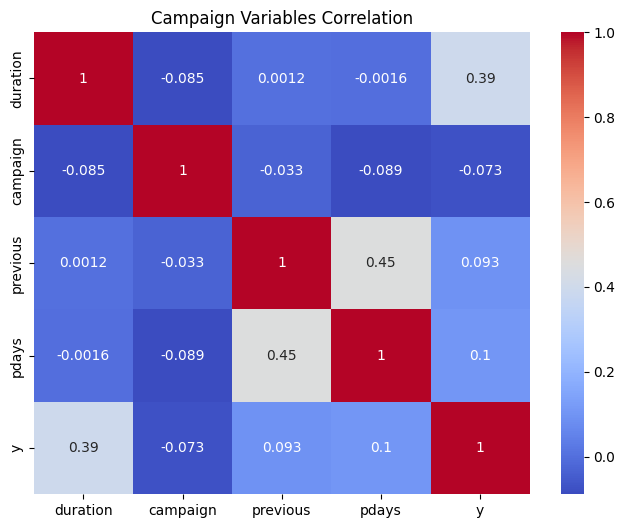

In [34]:
#Heatmap:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Campaign Variables Correlation')
plt.show()